In [ ]:
from google.colab import files
files.upload()

Saving test_dataset_1e-8.txt to test_dataset_1e-8.txt
Saving train_val_dataset_1e-8.txt to train_val_dataset_1e-8.txt


{'test_dataset_1e-8.txt': b'RID rs11585858_A rs4844600_A rs12037841_T rs4266886_T rs4562624_A rs6656401_A rs6661489_T rs1752684_A rs679515_T rs3818361_A rs6701713_A rs2093761_A rs2093760_A rs11576522_A rs12036785_C rs2296160_A rs61822977_G rs10863417_A rs10863418_C rs10779335_C rs10863420_A rs1830763_C rs1408078_T rs4844610_A rs1408077_A rs6697005_G rs11118328_C rs1060743_G rs10194375_A rs72846701_A rs6754293_T rs10200967_C rs17014923_T rs58402148_T rs11694743_G rs10929006_A rs4663095_A rs35114168_A rs11887884_T rs1530047_C rs76168490_G rs10207708_A rs11694264_A rs56117224_A rs56405130_A rs10166461_A rs749007_T rs749006_A rs55654668_T rs11682186_T rs72838215_A rs6431219_T rs744368_T rs11554586_A rs13032148_A rs6743470_T rs13410629_T rs13400939_A rs55646068_G rs10182292_A rs4663098_T rs7594230_A rs3845674_T rs10929007_A rs4663099_C rs4663100_C rs10929009_T rs11904144_G rs6431220_A rs7566991_A rs7601287_A rs7564197_A rs35103166_C rs72838226_C rs55669136_G rs7559175_G rs57724183_C rs75752

In [ ]:


import csv, re, os, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import StratifiedKFold
from collections import defaultdict

# ── Seed ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Dataset Files Name
TRAIN_VAL_FILE = "train_val_dataset_1e-8.txt"
TEST_FILE      = "test_dataset_1e-8.txt"
SNP_GENE_FILE  = "SNP_GENE_1e-8_filled.csv"

# Hyperparameters
BILSTM_HIDDEN  = 4
DROPOUT        = 0.2
L2_LAMBDA      = 1e-4
LR             = 1e-3
EPOCHS         = 50
BATCH_SIZE     = 32
N_FOLDS        = 5
PATIENCE       = 10
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


def build_snp_gene_map(snp_gene_file, snp_cols):

    snp_set = set(snp_cols)
    snp2genes   = defaultdict(list)
    snp2loc     = {}

    with open(snp_gene_file, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            rs  = row['rsID'].strip()
            sym = row['SYMBOL'].strip().lstrip('#')
            if rs not in snp_set or not sym:
                continue
            if sym not in snp2genes[rs]:
                snp2genes[rs].append(sym)
            loc = row['Location'].strip()
            try:
                chrom_str, pos_str = loc.split(':')
                pos_int   = int(pos_str.split('-')[0])
                # Chỉ giữ chr1-22
                if chrom_str.isdigit() and 1 <= int(chrom_str) <= 22:
                    snp2loc[rs] = (int(chrom_str), pos_int)
            except:
                pass

    gene2chrom_pos = {}
    for rs, genes in snp2genes.items():
        if rs in snp2loc:
            chrom, pos = snp2loc[rs]
            for g in genes:
                if g not in gene2chrom_pos or (chrom, pos) < gene2chrom_pos[g]:
                    gene2chrom_pos[g] = (chrom, pos)


    gene_order = sorted(gene2chrom_pos.keys(), key=lambda g: gene2chrom_pos[g])
    gene2chrom = {g: gene2chrom_pos[g][0] for g in gene_order}

    return snp2genes, gene_order, gene2chrom


def load_dataset(filepath):
    """Đọc file dataset → (snp_cols, X_raw, y)"""
    rows = []
    with open(filepath, 'r') as f:
        header = f.readline().strip().split()
        for line in f:
            rows.append(line.strip().split())

    snp_cols = header[1:-1]
    rs_ids = [col[:-2] for col in snp_cols]
    X_raw = []
    y     = []
    for row in rows:
        vals = row[1:-1]
        x    = []
        for v in vals:
            try:
                x.append(int(v))
            except:
                x.append(-1)
        X_raw.append(x)
        y.append(int(row[-1]))

    return rs_ids, np.array(X_raw), np.array(y)


def encode_2d(X_raw):
    N, S = X_raw.shape
    X_2d = np.zeros((N, S, 2), dtype=np.float32)
    for i in range(N):
        for j in range(S):
            v = X_raw[i, j]
            if v == -1:
                X_2d[i, j] = [0.0, 0.0]
            else:
                alt = float(v)
                ref = 2.0 - alt
                X_2d[i, j] = [ref, alt]
    return X_2d

def build_connectivity(rs_ids, snp2genes, gene_order):
    gene_idx = {g: i for i, g in enumerate(gene_order)}
    n_snp    = len(rs_ids)
    n_gene   = len(gene_order)

    mask = np.zeros((n_snp * 2, n_gene), dtype=np.float32)

    connected_snps = 0
    for snp_i, rs in enumerate(rs_ids):
        genes = snp2genes.get(rs, [])
        if genes:
            connected_snps += 1
        for g in genes:
            if g in gene_idx:
                g_i = gene_idx[g]
                mask[snp_i * 2,     g_i] = 1.0
                mask[snp_i * 2 + 1, g_i] = 1.0

    print(f" Connected SNP : {connected_snps}/{n_snp}")
    print(f"  Total edge : {int(mask.sum() / 2)}")
    return mask



class GenotypeDataset(Dataset):
    def __init__(self, X_2d, y):
        self.X = torch.FloatTensor(X_2d.reshape(X_2d.shape[0], -1))
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]



class PartialConnectedLayer(nn.Module):
    def __init__(self, mask):
        super().__init__()
        self.register_buffer('mask', torch.FloatTensor(mask))
        n_input, n_output = mask.shape
        self.weight = nn.Parameter(torch.randn(n_input, n_output) * 0.01)

    def forward(self, x):
        masked_w = self.weight * self.mask
        return x @ masked_w


class ChromBiLSTM(nn.Module):
    def __init__(self, hidden_size=4, dropout=0.5):
        super().__init__()
        self.hidden_size = hidden_size
        self.bilstm = nn.LSTM(
            input_size  = 1,
            hidden_size = hidden_size,
            num_layers  = 1,
            batch_first = True,
            bidirectional = True
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, gene_feats, chrom_gene_indices):
        batch_size = gene_feats.shape[0]
        outputs    = []

        for chrom in sorted(chrom_gene_indices.keys()):
            idx = chrom_gene_indices[chrom]
            if len(idx) == 0:
                continue
            chrom_feat = gene_feats[:, idx].unsqueeze(-1)
            out, _ = self.bilstm(chrom_feat)
            out    = self.dropout(out)
            out = out.reshape(batch_size, -1)
            outputs.append(out)


        return torch.cat(outputs, dim=1)


class DeepRisk(nn.Module):
    def __init__(self, mask, gene_order, gene2chrom, bilstm_hidden=4, dropout=0.5):
        super().__init__()

        self.gene_order = gene_order
        self.gene2chrom = gene2chrom
        self.n_gene     = len(gene_order)

        self.chrom_gene_indices = defaultdict(list)
        for i, g in enumerate(gene_order):
            chrom = gene2chrom.get(g, 0)
            if 1 <= chrom <= 22:
                self.chrom_gene_indices[chrom].append(i)

        total_bilstm_out = sum(
            len(idx) * bilstm_hidden * 2
            for idx in self.chrom_gene_indices.values()
        )

        self.partial_conn = PartialConnectedLayer(mask)
        self.relu = nn.ReLU()
        self.bilstm_module = ChromBiLSTM(
            hidden_size = bilstm_hidden,
            dropout     = dropout
        )
        self.fc = nn.Linear(total_bilstm_out, 1)
        self.sigmoid = nn.Sigmoid()

        print(f"  n_gene           : {self.n_gene}")
        print(f"  BiLSTM output dim: {total_bilstm_out}")
        print(f"  Chromosome List     : {len(self.chrom_gene_indices)}")

    def forward(self, x):
        gene_feat = self.relu(self.partial_conn(x))
        h = self.bilstm_module(gene_feat, self.chrom_gene_indices)
        score = self.sigmoid(self.fc(h))
        return score.squeeze(1)



def get_class_weights(y):
    n      = len(y)
    n_pos  = y.sum()
    n_neg  = n - n_pos
    w_pos  = n / (2.0 * n_pos)   # ω1
    w_neg  = n / (2.0 * n_neg)   # ω0
    return w_pos, w_neg


def weighted_bce_loss(pred, target, w_pos, w_neg):
    eps  = 1e-7
    loss = -(
        w_pos * target * torch.log(pred + eps) +
        w_neg * (1 - target) * torch.log(1 - pred + eps)
    )
    return loss.mean()


def train_epoch(model, loader, optimizer, w_pos, w_neg, l2_lambda):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        pred = model(X_batch)
        loss = weighted_bce_loss(pred, y_batch, w_pos, w_neg)

        l2_reg = sum(p.pow(2).sum() for p in model.bilstm_module.parameters())
        loss   = loss + l2_lambda * l2_reg

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_pred, all_true = [], []
    for X_batch, y_batch in loader:
        pred = model(X_batch.to(DEVICE)).cpu().numpy()
        all_pred.extend(pred)
        all_true.extend(y_batch.numpy())
    auc = roc_auc_score(all_true, all_pred)
    return auc, np.array(all_pred), np.array(all_true)



def train_one_fold(X_2d_tr, y_tr, X_2d_val, y_val,
                   mask, gene_order, gene2chrom, fold_idx):

    train_ds = GenotypeDataset(X_2d_tr,  y_tr)
    val_ds   = GenotypeDataset(X_2d_val, y_val)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)

    w_pos, w_neg = get_class_weights(y_tr)

    model = DeepRisk(
        mask          = mask,
        gene_order    = gene_order,
        gene2chrom    = gene2chrom,
        bilstm_hidden = BILSTM_HIDDEN,
        dropout       = DROPOUT
    ).to(DEVICE)

    optimizer    = torch.optim.Adam(model.parameters(), lr=LR)
    best_val_auc = 0.0
    best_state   = None
    patience_cnt = 0

    for epoch in range(1, EPOCHS + 1):
        train_loss            = train_epoch(model, train_loader, optimizer,
                                            w_pos, w_neg, L2_LAMBDA)
        val_auc, val_p, val_t = evaluate(model, val_loader)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            best_val_p   = val_p.copy()
            best_val_t   = val_t.copy()
            patience_cnt = 0
        else:
            patience_cnt += 1

        if patience_cnt >= PATIENCE:
            break

    print(f"    Fold {fold_idx:>2} — stopped ep {epoch:>3} | "
          f"Best Val AUC: {best_val_auc:.4f}")

    return best_val_auc, best_state, best_val_p, best_val_t



if __name__ == "__main__":
    rs_ids_tv, X_raw_tv, y_tv = load_dataset(TRAIN_VAL_FILE)
    rs_ids_te, X_raw_te, y_te = load_dataset(TEST_FILE)

    print(f"Train+Val: {len(y_tv):,} Samples | {len(rs_ids_tv)} SNPs")
    print(f"Test     : {len(y_te):,} Samples")
    print(f"Train+Val — case: {int(y_tv.sum())}, control: {int((1-y_tv).sum())}")
    print(f"Test      — case: {int(y_te.sum())}, control: {int((1-y_te).sum())}")

    snp2genes, gene_order, gene2chrom = build_snp_gene_map(SNP_GENE_FILE, set(rs_ids_tv))
    print(f"Gene : {len(gene_order)} | Chr: {sorted(set(gene2chrom.values()))}")

    X_2d_tv = encode_2d(X_raw_tv)
    X_2d_te = encode_2d(X_raw_te)
    print(f"X_2d_tv shape: {X_2d_tv.shape}  (N, num_snps, 2)")

    mask = build_connectivity(rs_ids_tv, snp2genes, gene_order)
    print(f"Connectivity mask: {mask.shape}")

    _model_tmp = DeepRisk(mask, gene_order, gene2chrom, BILSTM_HIDDEN, DROPOUT)
    n_params   = sum(p.numel() for p in _model_tmp.parameters() if p.requires_grad)
    print(f"Total param   : {n_params:,}")
    del _model_tmp

    print(f"{N_FOLDS}-FOLD CROSS-VALIDATION")

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    fold_aucs       = []
    all_oof_pred    = np.zeros(len(y_tv))
    all_oof_true    = np.zeros(len(y_tv))
    best_fold_auc   = 0.0
    best_fold_state = None

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_2d_tv, y_tv), start=1):
        print(f"\n  ── Fold {fold}/{N_FOLDS} ──")
        print(f"     Train: {len(tr_idx)} | Val: {len(val_idx)}")

        auc, state, val_p, val_t = train_one_fold(
            X_2d_tv[tr_idx], y_tv[tr_idx],
            X_2d_tv[val_idx], y_tv[val_idx],
            mask, gene_order, gene2chrom, fold
        )

        fold_aucs.append(auc)
        all_oof_pred[val_idx] = val_p
        all_oof_true[val_idx] = val_t

        if auc > best_fold_auc:
            best_fold_auc   = auc
            best_fold_state = state

    mean_auc = np.mean(fold_aucs)
    std_auc  = np.std(fold_aucs)
    oof_auc  = roc_auc_score(all_oof_true, all_oof_pred)

    print("\n" + "=" * 60)
    print(f"Result {N_FOLDS}-FOLD CROSS-VALIDATION")
    print("=" * 60)
    for i, a in enumerate(fold_aucs, 1):
        print(f"  Fold {i:>2}: AUC = {a:.4f}")
    print(f"  {'─'*35}")
    print(f"  Mean AUC   : {mean_auc:.4f} ± {std_auc:.4f}")
    print(f"  OOF AUC    : {oof_auc:.4f}")
    print(f"  Best fold  : {max(fold_aucs):.4f}  | Worst: {min(fold_aucs):.4f}")


    # Retrain on full dataset
    final_model = DeepRisk(
        mask          = mask,
        gene_order    = gene_order,
        gene2chrom    = gene2chrom,
        bilstm_hidden = BILSTM_HIDDEN,
        dropout       = DROPOUT
    ).to(DEVICE)
    final_model.load_state_dict(best_fold_state)

    # Retrain toàn bộ train_val từ best state (fine-tune thêm)
    full_loader  = DataLoader(
        GenotypeDataset(X_2d_tv, y_tv),
        batch_size=BATCH_SIZE, shuffle=True
    )
    test_loader  = DataLoader(
        GenotypeDataset(X_2d_te, y_te),
        batch_size=BATCH_SIZE
    )
    optimizer_final = torch.optim.Adam(final_model.parameters(), lr=LR * 0.5)
    w_pos_f, w_neg_f = get_class_weights(y_tv)

    for ep in range(10):
        loss = train_epoch(final_model, full_loader, optimizer_final,
                           w_pos_f, w_neg_f, L2_LAMBDA)

    # Test
    test_auc, test_pred, test_true = evaluate(final_model, test_loader)

    print(f"\n  CV Mean AUC (10-fold) : {mean_auc:.4f} ± {std_auc:.4f}")
    print(f"  OOF AUC               : {oof_auc:.4f}")
    print(f"  Test AUC (held-out)   : {test_auc:.4f}")

    # Classification report
    test_label = (test_pred >= 0.5).astype(int)
    print(f"\n  Classification Report (threshold=0.5):")
    print(classification_report(test_true.astype(int), test_label,
                                 target_names=['Control (0)', 'Case (1)']))

    print("  Odds Ratio Analysis:")
    for pct in [0.20, 0.10, 0.01]:
        sorted_idx = np.argsort(test_pred)[::-1]
        n_top      = max(1, int(len(sorted_idx) * pct))
        top_idx    = sorted_idx[:n_top]
        bot_idx    = sorted_idx[n_top:]
        td = test_true[top_idx].sum()
        te = n_top - td
        rd = test_true[bot_idx].sum()
        re_n = len(bot_idx) - rd
        if te > 0 and rd > 0 and re_n > 0:
            or_val = (td * re_n) / (te * rd)
            print(f"    Top {int(pct*100):>2}% vs Rest — Odds Ratio: {or_val:.3f} "
                  f"(top: {n_top}, TD={int(td)}, TE={int(te)})")


Device: cpu
BƯỚC 1 — Đọc dữ liệu
Train+Val: 1,000 mẫu | 1724 SNPs
Test     : 174 mẫu
Train+Val — case: 514, control: 486
Test      — case: 90, control: 84

BƯỚC 2 — Xây dựng SNP-Gene map
Gene riêng biệt: 98 | NST: [1, 2, 4, 6, 7, 8, 11, 14, 15, 17, 19, 20]

BƯỚC 3 — Encode 2D & Connectivity Matrix
X_2d_tv shape: (1000, 1724, 2)  (N, num_snps, 2)
  SNP có kết nối gene : 1724/1724
  Tổng kết nối (edges): 1735
Connectivity mask: (3448, 98)
  n_gene           : 98
  BiLSTM output dim: 784
  NST có gene      : 12
Tổng tham số    : 338,913

BƯỚC 4 — 5-FOLD CROSS-VALIDATION (theo paper)

  ── Fold 1/5 ──
     Train: 800 | Val: 200
  n_gene           : 98
  BiLSTM output dim: 784
  NST có gene      : 12
    Fold  1 — stopped ep  44 | Best Val AUC: 0.6868

  ── Fold 2/5 ──
     Train: 800 | Val: 200
  n_gene           : 98
  BiLSTM output dim: 784
  NST có gene      : 12
    Fold  2 — stopped ep  22 | Best Val AUC: 0.7103

  ── Fold 3/5 ──
     Train: 800 | Val: 200
  n_gene           : 98
  Bi

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

print("\n==========================================")
print("BƯỚC 8: TRỰC QUAN HÓA KẾT QUẢ ĐỂ BÁO CÁO")
print("==========================================")

# Ensure the 'plots' directory exists
os.makedirs('plots', exist_ok=True)


BƯỚC 8: TRỰC QUAN HÓA KẾT QUẢ ĐỂ BÁO CÁO


<Figure size 600x500 with 0 Axes>

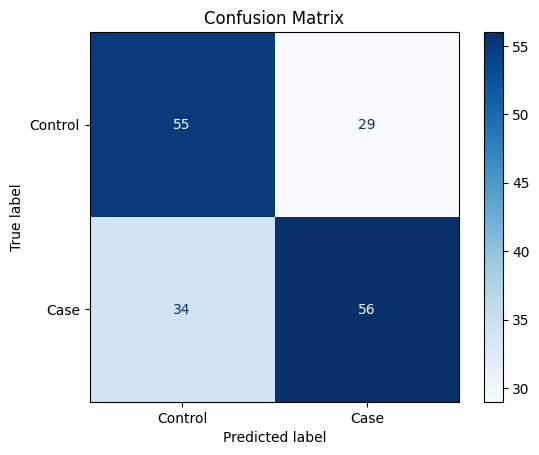

In [ ]:
# Confusion Matrix
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    test_true, test_label,
    display_labels=['Control', 'Case'],
    cmap='Blues', values_format='d'
)
plt.title('Confusion Matrix')
plt.savefig('plots/confusion_matrix_deeprisk.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

<Figure size 700x600 with 0 Axes>

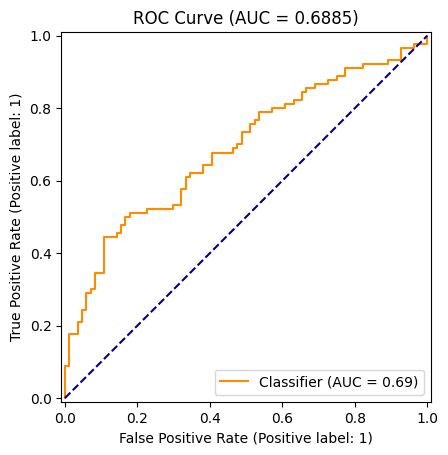

In [ ]:
# ROC Curve
plt.figure(figsize=(7, 6))
RocCurveDisplay.from_predictions(test_true, test_pred, color='darkorange')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title(f'ROC Curve (AUC = {test_auc:.4f})')
plt.savefig('plots/roc_curve_deeprisk.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

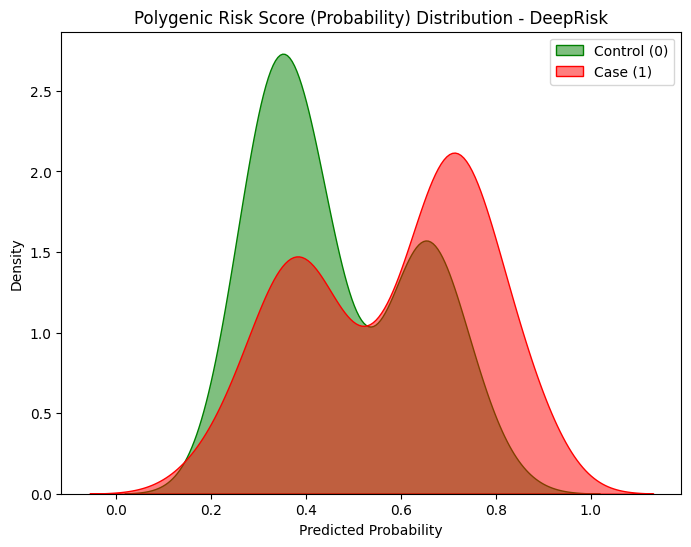

In [ ]:
# 8.3. Vẽ biểu đồ phân phối xác suất (Risk Score Distribution)
plt.figure(figsize=(8, 6))
sns.kdeplot(test_pred[test_true == 0], label='Control (0)', fill=True, color='green', alpha=0.5)
sns.kdeplot(test_pred[test_true == 1], label='Case (1)', fill=True, color='red', alpha=0.5)
plt.title('Polygenic Risk Score (Probability) Distribution - DeepRisk')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.legend()
plt.savefig('plots/risk_score_distribution_deeprisk.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    'True_Label': test_true,
    'Predicted_Probability': test_pred,
    'Predicted_Label': test_label
})

results_path = 'results/deeprisk_test_predictions.csv'
os.makedirs(os.path.dirname(results_path), exist_ok=True)
results_df.to_csv(results_path, index=False)
print(f"Detailed test predictions saved to: {results_path}")
display(results_df.head())

Detailed test predictions saved to: results/deeprisk_test_predictions.csv


,True_Label,Predicted_Probability,Predicted_Label
0,1.0,0.369268,0
1,0.0,0.369177,0
2,1.0,0.428953,0
3,0.0,0.309542,0
4,1.0,0.658491,1


In [ ]:
import torch

model_path = 'models/deeprisk_final_model.pt'
os.makedirs(os.path.dirname(model_path), exist_ok=True)
torch.save(final_model.state_dict(), model_path)
print(f"Final model saved to: {model_path}")

Final model saved to: models/deeprisk_final_model.pt


In [ ]:
import shutil
from google.colab import files

# Create a zip archive for plots
shutil.make_archive('plots_archive', 'zip', 'plots')
print("Zipping 'plots' directory...")
files.download('plots_archive.zip')

# Create a zip archive for results
shutil.make_archive('results_archive', 'zip', 'results')
print("Zipping 'results' directory...")
files.download('results_archive.zip')

print("✅ All requested files are ready for download.")

Zipping 'plots' directory...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Zipping 'results' directory...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All requested files are ready for download.


In [ ]:
shutil.make_archive('models_archive', 'zip', 'models')
print("Zipping 'models' directory...")
files.download('models_archive.zip')

Zipping 'models' directory...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# Calculate individual metrics
metrics = {
    "Accuracy" : accuracy_score(test_true, test_label),
    "Precision": precision_score(test_true, test_label, zero_division=0),
    "Recall"   : recall_score(test_true, test_label, zero_division=0),
    "F1-Score" : f1_score(test_true, test_label, zero_division=0),
    "AUC-ROC"  : roc_auc_score(test_true, test_pred)
}

print("Test Set Evaluation Metrics:")
for metric_name, value in metrics.items():
    print(f"  {metric_name:<10}: {value:.4f}")

Test Set Evaluation Metrics:
  Accuracy  : 0.6379
  Precision : 0.6588
  Recall    : 0.6222
  F1-Score  : 0.6400
  AUC-ROC   : 0.6885
